# **Capstone 2: EmporiUm Data Analysis**

- **Region:** Northeast  
    - **Sales Territory 1:** Florida  
        - **Manager:** Lana Ilana  
    - **Sales Territory 2:** South Carolina  
        - **Manager:** Len Jensen  

In [91]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Customer List**

In [92]:
clist = pd.read_csv('customer_list.csv', sep='|')  # Define separator as '|', not commas
clist.info()
clist.head()

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   cust_id       521 non-null    int64
 1   date          521 non-null    str  
 2   time          521 non-null    str  
 3   name          521 non-null    str  
 4   email         521 non-null    str  
 5   phone         520 non-null    str  
 6   sms-opt-out   520 non-null    str  
dtypes: int64(1), str(6)
memory usage: 28.6 KB


,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


**Product Categories**

In [93]:
pcategories = pd.read_csv('ProductCategories.csv')
pcategories.info()
pcategories.head()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB


,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


**Products**

In [94]:
products = pd.read_csv('Products.csv')
products.info()
products.head()

<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num       669 non-null    str  
 1   Product        669 non-null    str  
 2   CategoryID     669 non-null    int64
 3   SubcategoryID  669 non-null    str  
dtypes: int64(1), str(3)
memory usage: 21.0 KB


,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


**Store Detail**

In [95]:
sdetail = pd.read_csv('StoreDetail.csv')
sdetail.info()
sdetail.head()

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB


,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


**Store Sales**

In [96]:
ssales = pd.read_csv('StoreSales.csv')
ssales.info()
ssales.head()

<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  str    
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  str    
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.8 MB


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


## **Core Marketing Analysis**

### **Territory managers, store IDs, and cities for stores**

- Florida Store IDs:        719 - 729  
- South Carolina Store IDs: 852 - 853

In [97]:
# Create dataframe for Florida stores
fl_stores = sdetail[sdetail['State'] == 'Florida']
fl_ids = fl_stores["Store ID"].tolist()
fl_stores.rename(columns={'Store Location': 'City'}, inplace=True)

fl_stores

,City,State,Store ID,Territory Manager,Region,Region Director
26,Cape Canaveral,Florida,719,Lana Ilana,South,Andy Gisselquist
27,Fort Lauderdale,Florida,720,Lana Ilana,South,Andy Gisselquist
28,Jacksonville,Florida,721,Lana Ilana,South,Andy Gisselquist
29,Key West,Florida,722,Lana Ilana,South,Andy Gisselquist
30,Lakeland,Florida,723,Lana Ilana,South,Andy Gisselquist
31,Miami,Florida,724,Lana Ilana,South,Andy Gisselquist
32,Naples,Florida,725,Lana Ilana,South,Andy Gisselquist
33,Orlando,Florida,726,Lana Ilana,South,Andy Gisselquist
34,Sebring,Florida,727,Lana Ilana,South,Andy Gisselquist
35,Tallahassee,Florida,728,Lana Ilana,South,Andy Gisselquist


In [98]:
# Create dataframe for South Carolina stores
sc_stores = sdetail[sdetail['State'] == 'South Carolina']
sc_ids = sc_stores["Store ID"].tolist() 
sc_stores.rename(columns={'Store Location': 'City'}, inplace=True)

sc_stores

,City,State,Store ID,Territory Manager,Region,Region Director
98,Charleston,South Carolina,852,Len Jensen,South,Andy Gisselquist
99,Greenville,South Carolina,853,Len Jensen,South,Andy Gisselquist


### **Monthly revenue for in-store sales, covering full recorded period**

Florida Monthly Revenue:

In [99]:
fl_sales = ssales[ssales['Store ID'].isin(fl_ids)]                                                  # Use isin to filter store sales from previous South Carolina stores dataframe

fl_sales['Transaction Date'] = pd.to_datetime(fl_sales['Transaction Date'])                         # Convert Transaction Date to datetime
fl_sales['Transaction Date'] = fl_sales['Transaction Date'].dt.to_period('M')                       # Remove day from the transaction date

fl_revenue = fl_sales.groupby('Transaction Date')[['Sale Amount']].sum().reset_index()              # Displays and groups by transaction date, finding the sum of each month, reset index for cleaner display

fl_revenue.rename(columns={'Transaction Date': 'Month', 'Sale Amount': 'Florida Revenue'}, inplace=True)    # Rename columns, make numbers prettier with formatting
fl_revenue['Florida Revenue'] = fl_revenue['Florida Revenue'].map('${:,.2f}'.format)

fl_revenue

,Month,Florida Revenue
0,2022-01,"$48,143.95"
1,2022-02,"$46,257.35"
2,2022-03,"$53,541.25"
3,2022-04,"$49,505.25"
4,2022-05,"$58,326.64"
5,2022-06,"$48,683.24"
6,2022-07,"$57,545.77"
7,2022-08,"$48,656.98"
8,2022-09,"$42,839.10"
9,2022-10,"$49,508.42"


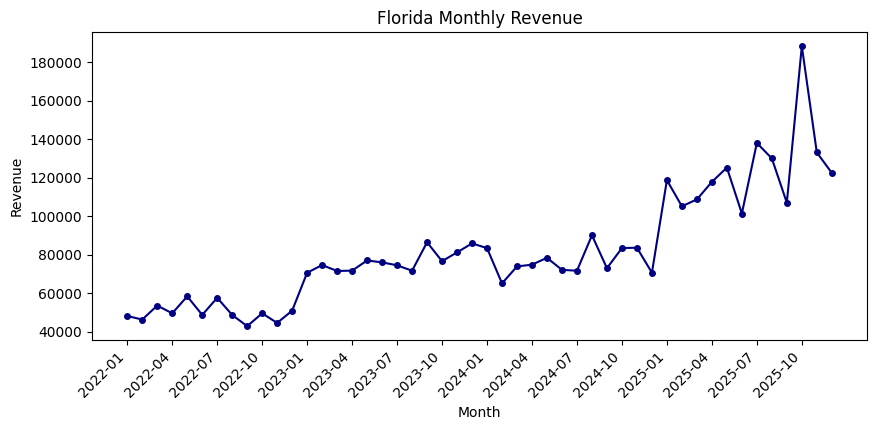

In [100]:
# Convert earlier formatting back to numeric
fl_line = fl_revenue.copy()
fl_line['Florida Revenue'] = fl_line['Florida Revenue'].str.replace('[$,]', '', regex=True).astype(float)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(fl_line['Month'].astype(str), fl_line['Florida Revenue'], color='navy', marker='o', markersize=4)

# Aesthetics
plt.title('Florida Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45, ha='right', ticks=range(0, len(fl_line), 3))

plt.show()

South Carolina Monthly Revenue:

In [101]:
sc_sales = ssales[ssales['Store ID'].isin(sc_ids)]                                                 # Use isin to filter store sales from previous South Carolina stores dataframe

sc_sales['Transaction Date'] = pd.to_datetime(sc_sales['Transaction Date'])                        # Convert Transaction Date to datetime
sc_sales['Transaction Date'] = sc_sales['Transaction Date'].dt.to_period('M')                      # Remove day from the transaction date

sc_revenue = sc_sales.groupby('Transaction Date')[['Sale Amount']].sum().reset_index()             # Displays and groups by transaction date, finding the sum of each month, reset index for cleaner display

sc_revenue.rename(columns={'Transaction Date': 'Month', 'Sale Amount': 'South Carolina Revenue'}, inplace=True)   # Rename columns, make numbers prettier with formatting
sc_revenue['South Carolina Revenue'] = sc_revenue['South Carolina Revenue'].map('${:,.2f}'.format)

sc_revenue

,Month,South Carolina Revenue
0,2022-01,"$9,640.38"
1,2022-02,"$9,763.98"
2,2022-03,"$8,366.63"
3,2022-04,"$8,929.63"
4,2022-05,"$5,396.03"
5,2022-06,"$7,196.23"
6,2022-07,"$13,083.78"
7,2022-08,"$8,916.43"
8,2022-09,"$8,155.79"
9,2022-10,"$10,330.27"


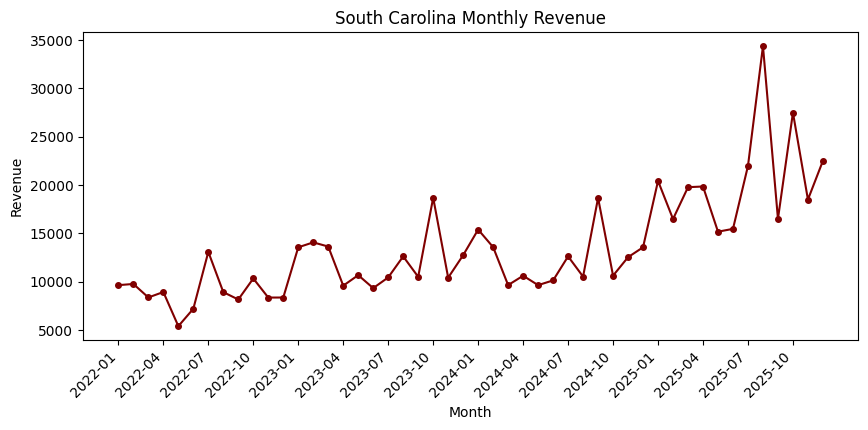

In [102]:
# Convert earlier formatting back to numeric
sc_line = sc_revenue.copy()
sc_line['South Carolina Revenue'] = sc_line['South Carolina Revenue'].str.replace('[$,]', '', regex=True).astype(float)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(sc_line['Month'].astype(str), sc_line['South Carolina Revenue'], color='maroon', marker='o', markersize=4)

# Aesthetics
plt.title('South Carolina Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45, ha='right', ticks=range(0, len(sc_line), 3))


plt.show()

### **Store performance ranked by revenue**

Florida Store Ranking:

In [103]:
fl_ranked = fl_sales.groupby('Store ID')[['Sale Amount']].sum()                          # Use previous sales dataframe grouped by the sum of Sale Amount

fl_ranked = fl_ranked.merge(fl_stores[["Store ID", "City"]], on="Store ID")              # Merge with previous stores dataframe using the Store ID to add City

fl_ranked = fl_ranked.sort_values("Sale Amount", ascending=False).reset_index(drop=True) # Aesthetics block. Sort by Sale Amount descending, fix index, reposition columns, and reformat numbers
fl_ranked = fl_ranked[['Store ID', 'City', 'Sale Amount']]
fl_ranked['Sale Amount'] = fl_ranked['Sale Amount'].map('${:,.2f}'.format)

fl_ranked

,Store ID,City,Sale Amount
0,724,Miami,"$618,846.25"
1,728,Tallahassee,"$541,670.66"
2,722,Key West,"$332,620.43"
3,719,Cape Canaveral,"$331,956.13"
4,721,Jacksonville,"$331,667.08"
5,727,Sebring,"$330,848.14"
6,729,Tampa,"$308,979.01"
7,720,Fort Lauderdale,"$302,270.07"
8,726,Orlando,"$297,891.71"
9,723,Lakeland,"$273,835.24"


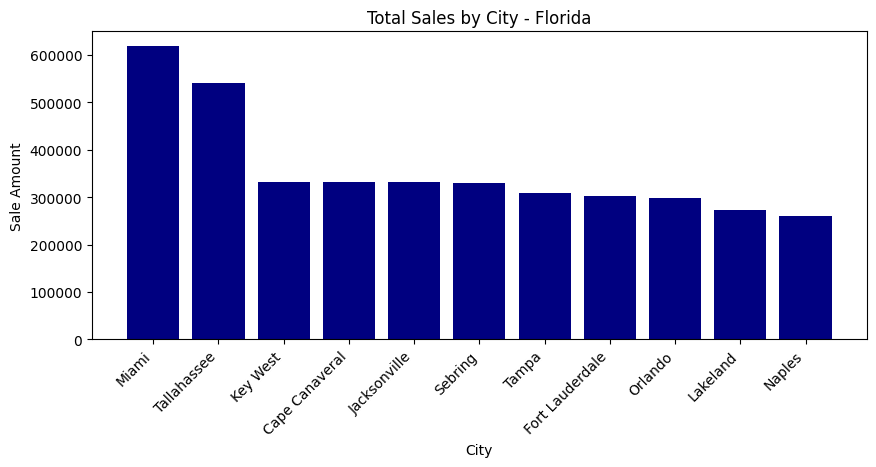

In [104]:
# Convert earlier formatting back to numeric
plot_data = fl_ranked.copy()
plot_data['Sale Amount'] = plot_data['Sale Amount'].str.replace('[$,]', '', regex=True).astype(float)

# Bar Chart
plt.figure(figsize=(10, 4))
plt.bar(plot_data['City'], plot_data['Sale Amount'], color='navy')

# Aesthetics
plt.title('Total Sales by City - Florida')
plt.xlabel('City')
plt.ylabel('Sale Amount')
plt.xticks(rotation=45, ha='right')

plt.show()

South Carolina Store Ranking:

In [105]:
sc_ranked = sc_sales.groupby('Store ID')[['Sale Amount']].sum()                          # Use previous sales dataframe grouped by the sum of Sale Amount

sc_ranked = sc_ranked.merge(sc_stores[["Store ID", "City"]], on="Store ID")              # Merge with previous stores dataframe using the Store ID to add City

sc_ranked = sc_ranked.sort_values("Sale Amount", ascending=False).reset_index(drop=True) # Aesthetics block. Sort by Sale Amount descending, fix index, reposition columns, and reformat numbers
sc_ranked = sc_ranked[['Store ID', 'City', 'Sale Amount']]
sc_ranked['Sale Amount'] = sc_ranked['Sale Amount'].map('${:,.2f}'.format)

sc_ranked

,Store ID,City,Sale Amount
0,853,Greenville,"$337,002.00"
1,852,Charleston,"$311,810.56"


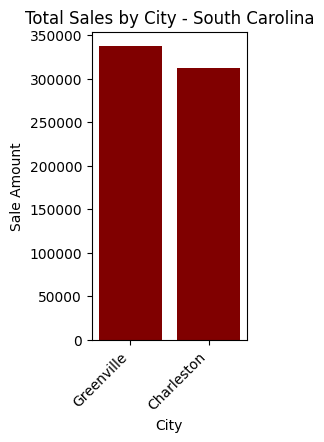

In [106]:
# Convert earlier formatting back to numeric
plot_data = sc_ranked.copy()
plot_data['Sale Amount'] = plot_data['Sale Amount'].str.replace('[$,]', '', regex=True).astype(float)

# Bar Chart
plt.figure(figsize=(2, 4))
plt.bar(plot_data['City'], plot_data['Sale Amount'], color='maroon')

# Aesthetics
plt.title('Total Sales by City - South Carolina')
plt.xlabel('City')
plt.ylabel('Sale Amount')
plt.xticks(rotation=45, ha='right')

plt.show()

### Top customers in each territory

Top Florida Customers:

In [107]:
fl_rewards = fl_sales[fl_sales['RewardsID'].notna()]                                   # Remove sales that do not have a RewardsID
fl_customers = fl_rewards.merge(clist, left_on='RewardsID', right_on='cust_id')        # Merge customer_list and StoreSales with cust_id and RewardsID

fl_customers = fl_customers.groupby(["RewardsID", "name"])[["Sale Amount"]].sum().sort_values("Sale Amount", ascending=False).reset_index()  # Group to find sum of sales for each customer

fl_customers['RewardsID'] = fl_customers['RewardsID'].astype(int)                      # Aesthetic block: Float to int, rename columns, remove unnecessary columns, and format numbers
fl_customers.rename(columns={'RewardsID':'Rewards ID', 'name':'Name'}, inplace=True)
fl_customers = fl_customers[['Rewards ID', 'Name', 'Sale Amount']]                    
fl_customers['Sale Amount'] = fl_customers['Sale Amount'].map('${:,.2f}'.format)

fl_customers.head(10)

,Rewards ID,Name,Sale Amount
0,47,Stanley H.,"$4,954.99"
1,259,Todd Chavez,"$4,549.16"
2,190,Huck,"$4,415.78"
3,335,John Locke,"$3,631.94"
4,164,Dr. Ray Flemming,"$3,535.88"
5,418,Ernie,"$3,387.58"
6,56,Leslie Knope,"$3,355.68"
7,143,Billy Abbott,"$3,325.45"
8,212,Geoffrey,"$3,225.15"
9,215,Lisa W.,"$3,204.56"


Top South Carolina Customers

In [108]:
sc_rewards = sc_sales[sc_sales['RewardsID'].notna()]                                   # Remove sales that do not have a RewardsID
sc_customers = sc_rewards.merge(clist, left_on='RewardsID', right_on='cust_id')        # Merge customer_list and StoreSales with cust_id and RewardsID

sc_customers = sc_customers.groupby(["RewardsID", "name"])[["Sale Amount"]].sum().sort_values("Sale Amount", ascending=False).reset_index()  # Group to find sum of sales for each customer

sc_customers['RewardsID'] = sc_customers['RewardsID'].astype(int)                      # Aesthetic block: Float to int, rename columns, remove unnecessary columns, and format numbers
sc_customers.rename(columns={'RewardsID':'Rewards ID', 'name':'Name'}, inplace=True)
sc_customers = sc_customers[['Rewards ID', 'Name', 'Sale Amount']]                    
sc_customers['Sale Amount'] = sc_customers['Sale Amount'].map('${:,.2f}'.format)

sc_customers.head(10)

,Rewards ID,Name,Sale Amount
0,340,Jin Kwon,"$1,786.05"
1,404,Roman Roy,"$1,778.84"
2,213,Jazz,"$1,763.70"
3,74,Ben Chang,"$1,566.60"
4,280,Cal Abar,"$1,396.50"
5,227,Debra Morgan,"$1,388.56"
6,10,Emily,"$1,365.72"
7,243,Dayanara Diaz,"$1,359.30"
8,48,Andy B.,"$1,334.92"
9,478,AJ Soprano,"$1,322.16"


### **Number of transactions by product category + total sales revenue per month by category**

**Florida Transactions:**

In [109]:
# Three way merge needed between *fl_sales(Prod Num)*, *products(Prod Num + CategoryID)*, and *pcategories(CategoryID)*

fl_category = fl_sales.merge(products[['Prod Num', 'CategoryID']], on='Prod Num')                   # Merge fl_sales with products to get category info
fl_category = fl_category.merge(pcategories[['CategoryID', 'Category']], on='CategoryID')           # Merge with pcategories to get category name
fl_category = fl_category.merge(fl_stores[['Store ID', 'City']], on='Store ID')                     # Merge with fl_stores to get territory/city info

fl_category_summary = fl_category.groupby(['Transaction Date', 'City', 'Category']).agg(            # Group by Month, City, and Category
    Transactions=('Sale Amount', 'count'),
    Total_Revenue=('Sale Amount', 'sum')
).reset_index()

fl_category_summary['Total_Revenue'] = fl_category_summary['Total_Revenue'].map('${:,.2f}'.format)  # Format revenue

fl_category_summary

,Transaction Date,City,Category,Transactions,Total_Revenue
0,2022-01,Cape Canaveral,Apparel and Merchandise,32,"$1,330.24"
1,2022-01,Cape Canaveral,Art Supplies,66,"$1,130.14"
2,2022-01,Cape Canaveral,Books (General),12,$504.32
3,2022-01,Cape Canaveral,Stationery and Supplies,44,$359.26
4,2022-01,Cape Canaveral,Technology & Accessories,35,"$10,007.69"
...,...,...,...,...,...
3128,2025-12,Tampa,Art Supplies,242,"$6,296.29"
3129,2025-12,Tampa,Books (General),20,$632.88
3130,2025-12,Tampa,Stationery and Supplies,132,"$1,738.55"
3131,2025-12,Tampa,Technology & Accessories,140,"$61,104.96"


**South Carolina Transactions:**

In [110]:
# Three way merge needed between *sc_sales(Prod Num)*, *products(Prod Num + CategoryID)*, and *pcategories(CategoryID)*

sc_category = sc_sales.merge(products[['Prod Num', 'CategoryID']], on='Prod Num')                   # Merge sc_sales with products to get category info
sc_category = sc_category.merge(pcategories[['CategoryID', 'Category']], on='CategoryID')           # Merge with pcategories to get category name
sc_category = sc_category.merge(sc_stores[['Store ID', 'City']], on='Store ID')                     # Merge with sc_stores to get territory/city info

sc_category_summary = sc_category.groupby(['Transaction Date', 'City', 'Category']).agg(            # Group by Month, City, then Category
    Transactions=('Sale Amount', 'count'),
    Total_Revenue=('Sale Amount', 'sum')
).reset_index()

sc_category_summary['Total_Revenue'] = sc_category_summary['Total_Revenue'].map('${:,.2f}'.format)  # Format revenue

sc_category_summary

,Transaction Date,City,Category,Transactions,Total_Revenue
0,2022-01,Charleston,Apparel and Merchandise,56,"$1,327.20"
1,2022-01,Charleston,Art Supplies,22,"$1,499.63"
2,2022-01,Charleston,Books (General),8,$209.44
3,2022-01,Charleston,Stationery and Supplies,33,$292.27
4,2022-01,Charleston,Technology & Accessories,70,"$42,727.37"
...,...,...,...,...,...
565,2025-12,Greenville,Art Supplies,88,"$2,590.83"
566,2025-12,Greenville,Books (General),4,$70.80
567,2025-12,Greenville,Stationery and Supplies,253,"$2,376.88"
568,2025-12,Greenville,Technology & Accessories,126,"$62,307.35"


### **Comparison of City Revenue and Population**

In [111]:
fl_pop = pd.read_csv('population_florida.csv')
fl_pop

,City,Population
0,Miami,459745
1,Tallahassee,201875
2,Key West,25720
3,Cape Canaveral,10006
4,Jacksonville,977670
5,Sebring,11382
6,Tampa,401618
7,Fort Lauderdale,185604
8,Orlando,319758
9,Lakeland,119961


In [112]:
sc_pop = pd.read_csv('population_southcarolina.csv')
sc_pop

,City,Population
0,Charleston,154338
1,Greenville,72935


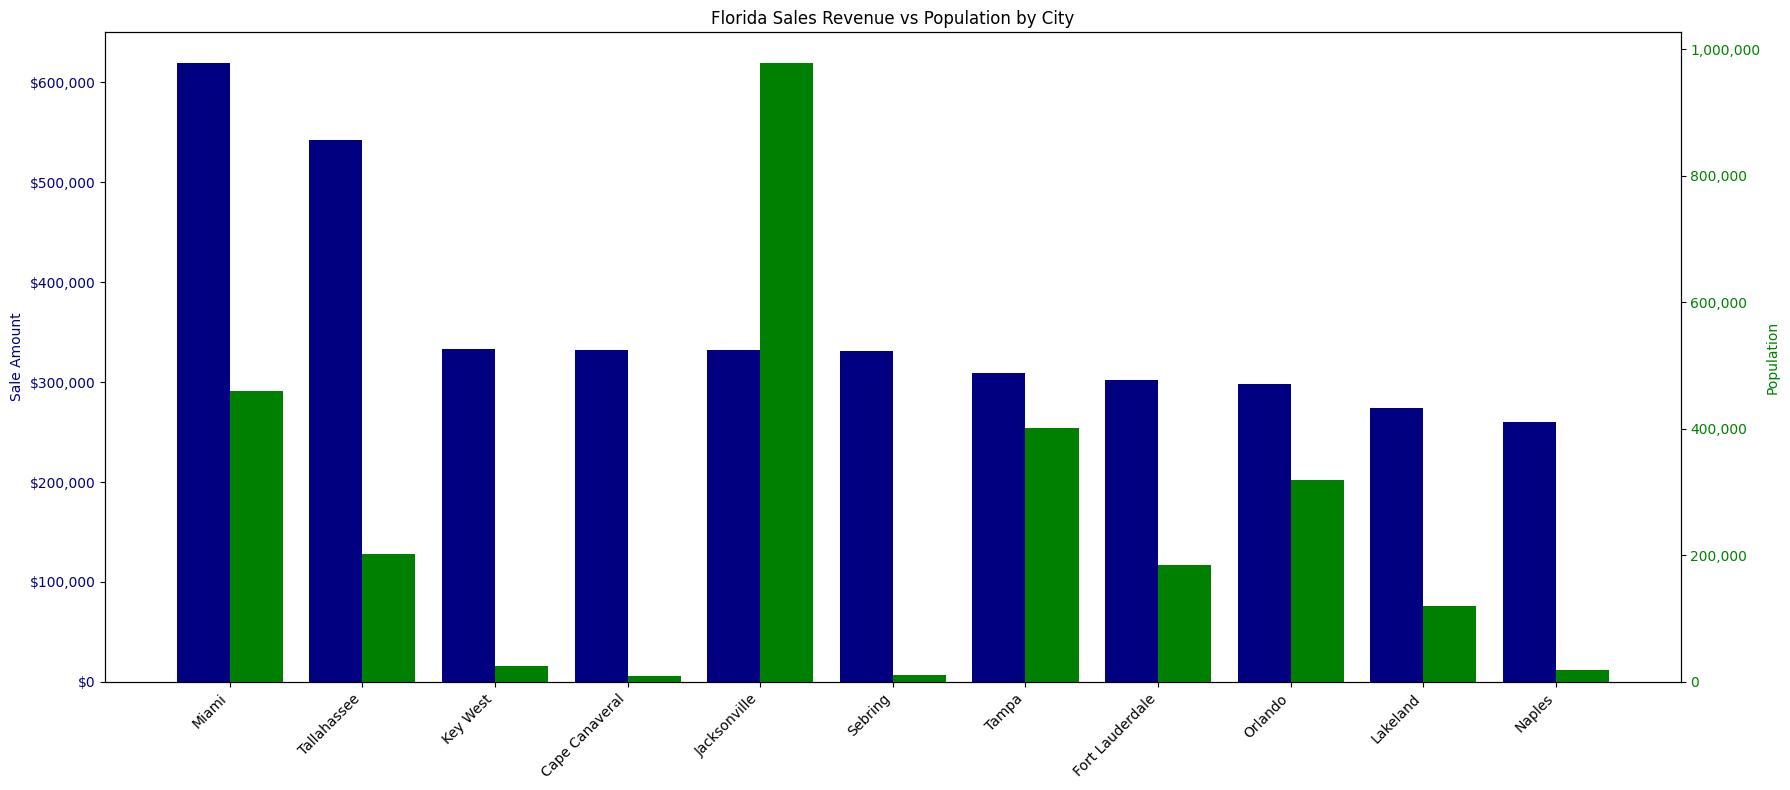

In [ ]:
# Convert previous formatting back to numeric values
fl_popbar = fl_ranked.copy()
fl_popbar['Sale Amount'] = fl_popbar['Sale Amount'].str.replace('[$,]', '', regex=True).astype(float) # regex searches for strings in Sale Amount to convert to numeric values

# Merge with fl_popbar
fl_popbar = fl_popbar.merge(fl_pop, on='City')

# Bar chart creation
x = np.arange(len(fl_popbar['City']))                                                       # X positions for each city
fig, ax1 = plt.subplots(figsize=(18, 8))                                                    # Figure Size

# Left Y-axis Sale Amount bars and labels 
ax1.bar(x - 0.4/2, fl_popbar['Sale Amount'], 0.4, color='navy', label='Sales Revenue')      # Sets x positions for bar half shift left, height value, width, color, and  
ax1.set_ylabel('Sale Amount', color='navy')                                                 # Label and color
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))                 # Formats values to dollar
ax1.tick_params(axis='y', labelcolor='navy')                                                # Sets color for left Y-Axis labels

# Right Y-axis Population bars and labels
ax2 = ax1.twinx()                                                                           # Creates second y-axis bars for population
ax2.bar(x + 0.4/2, fl_popbar['Population'], 0.4, color='green', label='Population')
ax2.set_ylabel('Population', color='green')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.tick_params(axis='y', labelcolor='green')

# Labels and formatting
plt.title('Florida Sales Revenue vs Population by City')
ax1.set_xticks(x)
ax1.set_xticklabels(fl_popbar['City'], rotation=45, ha='right')                             # Turns x-axis labels to avoid crowding

plt.tight_layout()
plt.show()

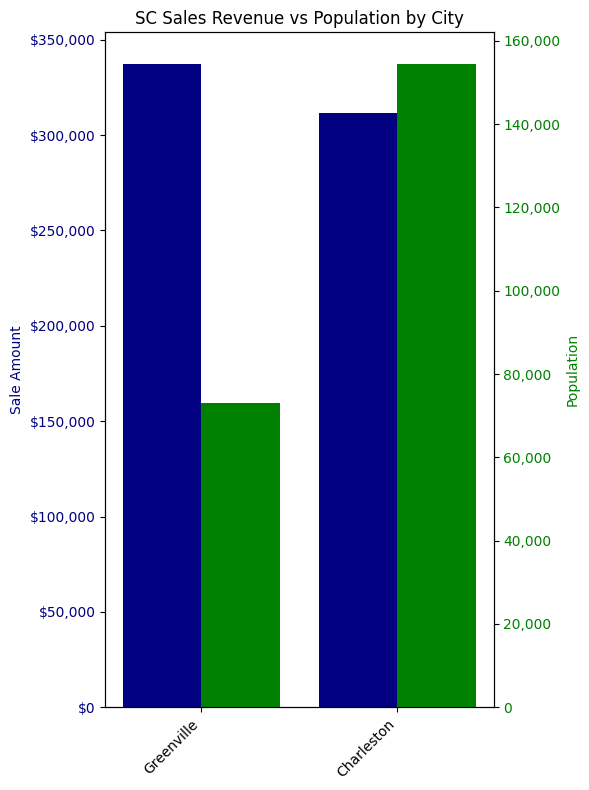

In [ ]:
# Convert previous formatting back to numeric values
sc_popbar = sc_ranked.copy()
sc_popbar['Sale Amount'] = sc_popbar['Sale Amount'].str.replace('[$,]', '', regex=True).astype(float) # regex searches for strings in Sale Amount to convert to numeric values

# Merge with sc_popbar
sc_popbar = sc_popbar.merge(sc_pop, on='City')

# Bar chart creation
x = np.arange(len(sc_popbar['City']))                                                       # X positions for each city
fig, ax1 = plt.subplots(figsize=(6, 8))                                                     # Figure Size

# Left Y-axis Sale Amount bars and labels 
ax1.bar(x - 0.4/2, sc_popbar['Sale Amount'], 0.4, color='navy', label='Sales Revenue')      # Sets x positions for bar half shift left, height value, width, color, and  
ax1.set_ylabel('Sale Amount', color='navy')                                                 # Label
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))                 # Formats values to dollar
ax1.tick_params(axis='y', labelcolor='navy')                                                # Sets color for left Y-Axis labels

# Right Y-axis Population bars and labels
ax2 = ax1.twinx()                                                                           # Creates second y-axis bars for population
ax2.bar(x + 0.4/2, sc_popbar['Population'], 0.4, color='green', label='Population')
ax2.set_ylabel('Population', color='green')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.tick_params(axis='y', labelcolor='green')

# Labels and formatting
plt.title('SC Sales Revenue vs Population by City')
ax1.set_xticks(x)
ax1.set_xticklabels(sc_popbar['City'], rotation=45, ha='right')                             # Turns x-axis labels to avoid crowding

plt.tight_layout()
plt.show()

## **My Recommendation**

Looking at the last two bar graphs comparing revenue along with population, I believe it is important to look at  
**stores that are bringing in a high revenue in comparison to their population**, and learn the reasons for such high revenue despite their population.  
Examples of these high performing stores include **Cape Canaveral**, and **Sebring** in Florida, and **Greenville** in South Carolina.  
**Stores that aren't doing as well in ther population** include **Miami** and **Jacksonville** in Florida, and **Charleston** in South Carolina,  
these stores should look to the higher performing stores and **compare factors that may be reducing their sales**, such as **competition**, **size**, and **location** within the city.